In [28]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv')

print("Shape:", df.shape)
df.head()

Shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 1. Quick Preprocessing

In [29]:
# Remove duplicates
df = df.drop_duplicates()

# Remove BMI outliers
df = df[df['BMI'] <= 60]

# Drop low variance column
df = df.drop(columns=['CholCheck'])

# Separate features and target
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

print("Shape after cleaning:", df.shape)
print("Features:", X.shape)
print("Target:", y.shape)


Shape after cleaning: (228669, 21)
Features: (228669, 20)
Target: (228669,)


Basic cleaning applied from Phase 2 — duplicates removed, 
BMI outliers dropped, CholCheck removed. 
Now ready for feature engineering.

## 2. Feature Importance Analysis

/tmp/ipykernel_55/645268313.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance.values, y=rf_importance.index, palette='viridis')


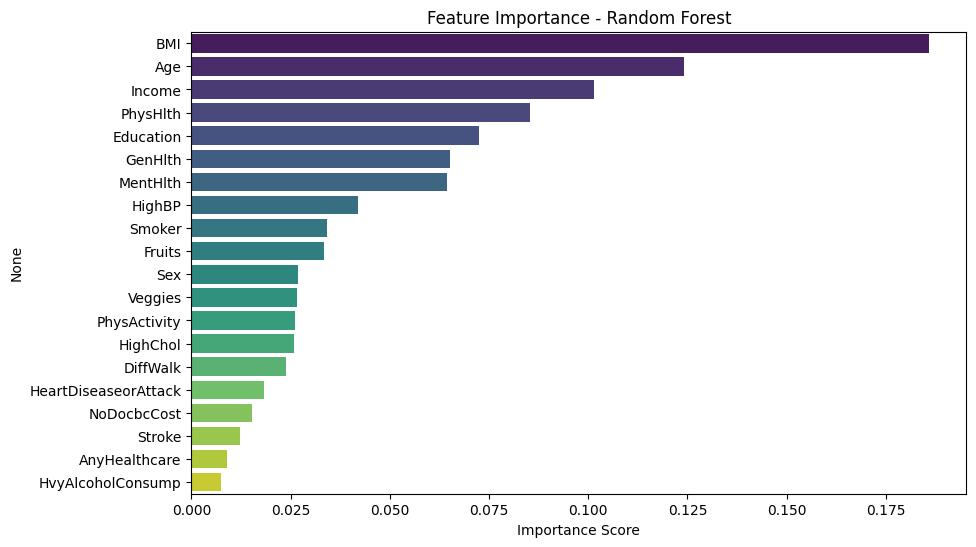

BMI                     0.185988
Age                     0.124179
Income                  0.101400
PhysHlth                0.085259
Education               0.072566
GenHlth                 0.065046
MentHlth                0.064400
HighBP                  0.042083
Smoker                  0.034146
Fruits                  0.033403
Sex                     0.026764
Veggies                 0.026666
PhysActivity            0.026198
HighChol                0.025844
DiffWalk                0.023760
HeartDiseaseorAttack    0.018297
NoDocbcCost             0.015315
Stroke                  0.012283
AnyHealthcare           0.008861
HvyAlcoholConsump       0.007544
dtype: float64


In [30]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=X.columns)
rf_importance = rf_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=rf_importance.values, y=rf_importance.index, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

print(rf_importance)


Random Forest calculates feature importance by measuring 
how much each feature reduces impurity across all trees. 
Higher score = more important feature.

/tmp/ipykernel_55/4200415645.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lr_importance.values, y=lr_importance.index, palette='magma')


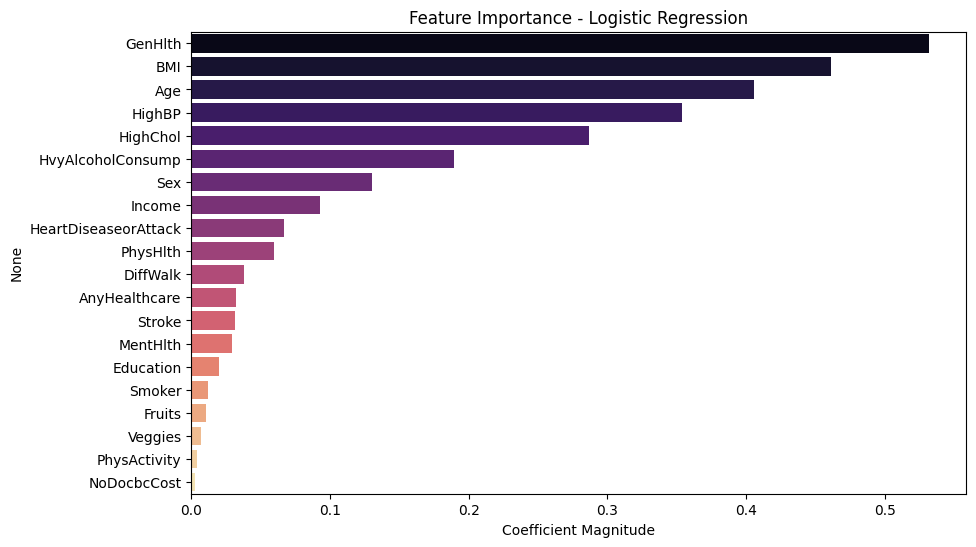

GenHlth                 0.532261
BMI                     0.460899
Age                     0.405557
HighBP                  0.354059
HighChol                0.286727
HvyAlcoholConsump       0.189117
Sex                     0.130344
Income                  0.093088
HeartDiseaseorAttack    0.066553
PhysHlth                0.059312
DiffWalk                0.038052
AnyHealthcare           0.032403
Stroke                  0.031280
MentHlth                0.029177
Education               0.020195
Smoker                  0.011906
Fruits                  0.010456
Veggies                 0.006773
PhysActivity            0.003775
NoDocbcCost             0.002760
dtype: float64


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_scaled, y)

lr_importance = pd.Series(abs(lr.coef_[0]), index=X.columns)
lr_importance = lr_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=lr_importance.values, y=lr_importance.index, palette='magma')
plt.title('Feature Importance - Logistic Regression')
plt.xlabel('Coefficient Magnitude')
plt.show()

print(lr_importance)



Logistic Regression importance is based on coefficient 
magnitude after scaling. Larger absolute coefficient = 
stronger influence on diabetes prediction.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:09:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/tmp/ipykernel_55/1466831482.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_importance.values, y=xgb_importance.index, palette='plasma')


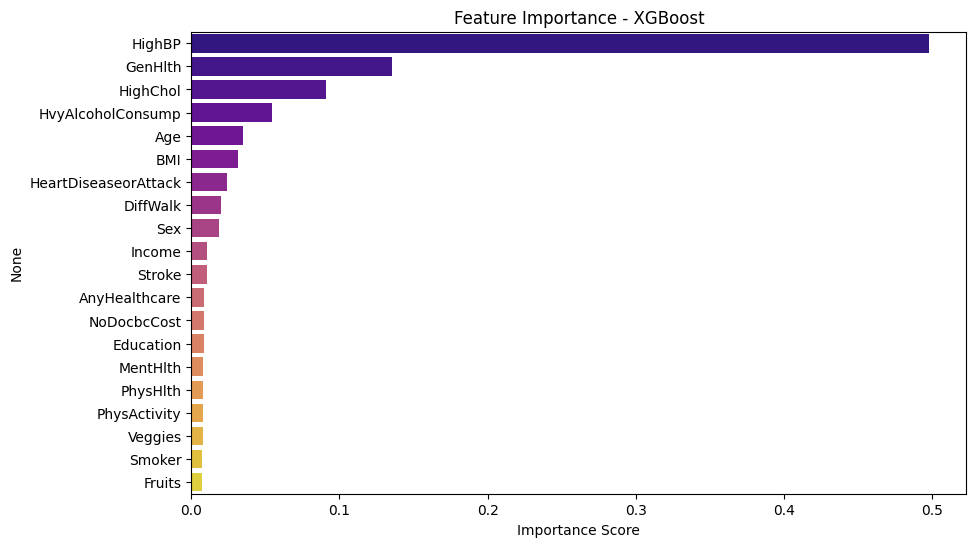

HighBP                  0.498413
GenHlth                 0.135571
HighChol                0.090759
HvyAlcoholConsump       0.054168
Age                     0.034779
BMI                     0.031267
HeartDiseaseorAttack    0.023811
DiffWalk                0.020309
Sex                     0.018522
Income                  0.010614
Stroke                  0.010606
AnyHealthcare           0.008683
NoDocbcCost             0.008583
Education               0.008432
MentHlth                0.008094
PhysHlth                0.007968
PhysActivity            0.007785
Veggies                 0.007702
Smoker                  0.007019
Fruits                  0.006916
dtype: float32


In [32]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, 
                    eval_metric='logloss', use_label_encoder=False)
xgb.fit(X, y)

xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns)
xgb_importance = xgb_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=xgb_importance.values, y=xgb_importance.index, palette='plasma')
plt.title('Feature Importance - XGBoost')
plt.xlabel('Importance Score')
plt.show()

print(xgb_importance)



XGBoost calculates feature importance based on how many 
times a feature is used to split data across all boosted 
trees. It is one of the most reliable methods for 
feature importance in tabular datasets.

/tmp/ipykernel_55/3321195934.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chi2_importance.values, y=chi2_importance.index, palette='coolwarm')


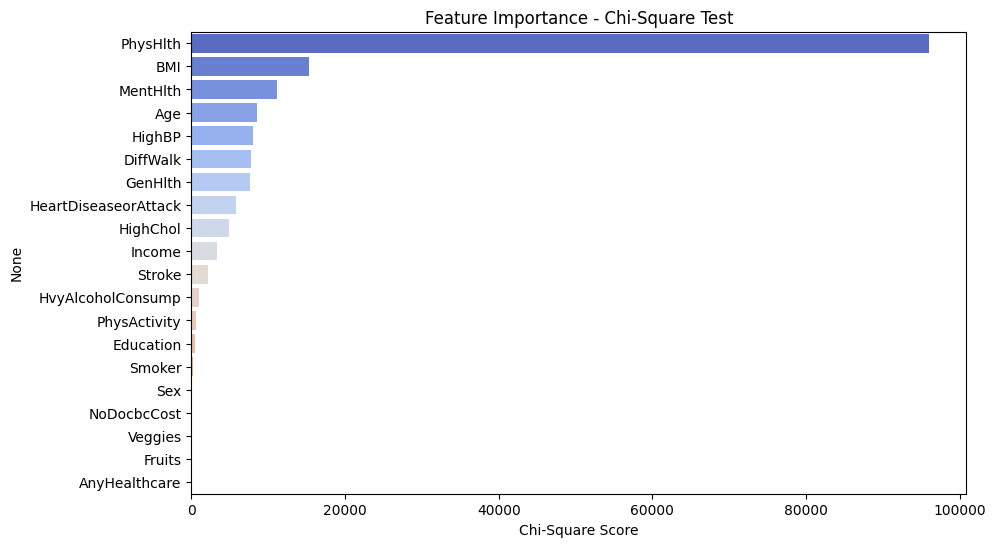

PhysHlth                96076.720529
BMI                     15253.361643
MentHlth                11179.765373
Age                      8529.081738
HighBP                   8050.576397
DiffWalk                 7758.275235
GenHlth                  7600.130235
HeartDiseaseorAttack     5793.920377
HighChol                 4853.899111
Income                   3323.322133
Stroke                   2150.639195
HvyAlcoholConsump         930.797238
PhysActivity              603.880430
Education                 474.309398
Smoker                    253.350321
Sex                       140.935313
NoDocbcCost                81.013968
Veggies                    80.567173
Fruits                     53.387387
AnyHealthcare               7.942328
dtype: float64


In [33]:
from sklearn.feature_selection import chi2, SelectKBest

# Chi2 needs non-negative values so use original X (not scaled)
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X, y)

chi2_importance = pd.Series(chi2_selector.scores_, index=X.columns)
chi2_importance = chi2_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=chi2_importance.values, y=chi2_importance.index, palette='coolwarm')
plt.title('Feature Importance - Chi-Square Test')
plt.xlabel('Chi-Square Score')
plt.show()

print(chi2_importance)



Chi-Square test measures the statistical relationship 
between each feature and the target variable. 
Higher score = stronger statistical dependency 
between that feature and diabetes outcome.

In [34]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_importance = pd.Series(mi_scores, index=X.columns)
mi_importance = mi_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=mi_importance.values, y=mi_importance.index, palette='rocket')
plt.title('Feature Importance - Mutual Information')
plt.xlabel('Mutual Information Score')
plt.show()

print(mi_importance)



KeyboardInterrupt: 

Mutual Information measures how much knowing a feature 
reduces uncertainty about the target variable. 
Unlike Chi-Square, it captures both linear and 
non-linear relationships between features and target.

In [ ]:
# Normalize all scores to 0-1 range for fair comparison
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

combined = pd.DataFrame({
    'RandomForest': normalize(rf_importance),
    'LogisticReg': normalize(lr_importance),
    'XGBoost': normalize(xgb_importance),
    'Chi2': normalize(chi2_importance),
    'MutualInfo': normalize(mi_importance)
})

combined['Average'] = combined.mean(axis=1)
combined = combined.sort_values('Average', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=combined['Average'], y=combined.index, palette='viridis')
plt.title('Average Feature Importance - All 5 Methods')
plt.xlabel('Average Normalized Score')
plt.show()

print(combined['Average'].sort_values(ascending=False))



Combining all 5 methods gives a balanced view of feature 
importance. Features that rank consistently high across 
multiple methods are the most reliable predictors of diabetes.

## 3. Feature Engineering - Creating New Features

In [ ]:
# Combining heart-related risk factors
X['CardioRisk'] = X['HighBP'] + X['HighChol'] + X['HeartDiseaseorAttack'] + X['Stroke']

print("CardioRisk value counts:")
print(X['CardioRisk'].value_counts().sort_index())



CardioRisk combines HighBP, HighChol, HeartDiseaseorAttack 
and Stroke into a single score (0-4). Higher score means 
more cardiovascular risk factors present. Since these 
factors are medically linked to diabetes, combining them 
may give the model a stronger signal.

In [ ]:
# Healthy lifestyle indicators
X['LifestyleScore'] = X['PhysActivity'] + X['Fruits'] + X['Veggies'] - X['Smoker'] - X['HvyAlcoholConsump']

print("\nLifestyleScore stats:")
print(X['LifestyleScore'].describe())



LifestyleScore combines positive habits (PhysActivity, 
Fruits, Veggies) minus negative habits (Smoker, 
HvyAlcoholConsump). Higher score = healthier lifestyle. 
People with healthier lifestyles are expected to have 
lower diabetes risk.

In [ ]:
# Combining two strongest predictors
X['BMI_Age_Risk'] = X['BMI'] * X['Age']

print("BMI_Age_Risk stats:")
print(X['BMI_Age_Risk'].describe())



BMI_Age_Risk multiplies BMI and Age together. Both are 
top predictors individually — older people with higher 
BMI are at significantly greater diabetes risk. 
This interaction feature captures that combined effect.

In [ ]:
# Healthcare access indicator
X['HealthAccess'] = X['AnyHealthcare'] - X['NoDocbcCost']

print("\nHealthAccess value counts:")
print(X['HealthAccess'].value_counts().sort_index())



HealthAccess combines having healthcare coverage 
(AnyHealthcare) minus inability to afford doctor 
(NoDocbcCost). Higher score means better access 
to healthcare, which may reduce undiagnosed diabetes.

In [ ]:
# Overall metabolic risk score
X['MetabolicRisk'] = X['BMI'] + (X['HighBP'] * 10) + (X['HighChol'] * 10)

print("\nMetabolicRisk stats:")
print(X['MetabolicRisk'].describe())



MetabolicRisk combines BMI with High Blood Pressure 
and High Cholesterol (weighted by 10 to reflect their 
clinical significance). This captures overall metabolic 
health — a key indicator of diabetes risk.

## 4. Testing New Features with LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train LightGBM
lgbm = lgb.LGBMClassifier(random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)

# Evaluate
y_pred = lgbm.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

LightGBM is used to quickly evaluate how well our 
engineered features perform. It is fast, efficient, 
and works well with default settings on tabular data.

## 5. Dropping Weak Features

In [ ]:
# Drop weakest features identified from importance analysis
weak_features = ['Stroke', 'NoDocbcCost']
X = X.drop(columns=weak_features)

print("Shape after dropping weak features:", X.shape)
print("Remaining features:", X.columns.tolist())



Stroke (avg score 0.034) and NoDocbcCost (avg score 0.009) 
were dropped as they ranked lowest across all 5 importance 
methods consistently. Removing them reduces noise and 
simplifies the model without losing useful information.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

lgbm2 = lgb.LGBMClassifier(random_state=42, verbose=-1)
lgbm2.fit(X_train, y_train)

y_pred2 = lgbm2.predict(X_test)
print("Accuracy after dropping weak features:", round(accuracy_score(y_test, y_pred2), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred2))



Re-testing LightGBM after dropping weak features 
to verify that removing them doesn't hurt performance.

## 6. K-Means Clustering as New Feature

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Scale first for clustering
scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(X)

# Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
X['HealthCluster'] = kmeans.fit_predict(X_km)

print("Cluster distribution:")
print(X['HealthCluster'].value_counts().sort_index())



K-Means clustering groups people into 3 clusters based 
on all their health features. Each cluster represents 
a different health profile — for example low risk, 
medium risk, and high risk groups. This cluster label 
becomes a new feature that captures overall health 
pattern of each person.

In [ ]:
# Check diabetes rate per cluster
temp = X.copy()
temp['Diabetes'] = y.values
print("Diabetes rate per cluster:")
print(temp.groupby('HealthCluster')['Diabetes'].mean().round(4) * 100)

K-Means successfully identified meaningful health groups. 
Cluster 1 shows 28% diabetes rate compared to only 5% 
in Cluster 0, confirming that clustering captured 
genuine health risk patterns. HealthCluster is a 
valuable new feature for model training.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale all features including new ones
scaler_final = StandardScaler()
X_final = pd.DataFrame(scaler_final.fit_transform(X), columns=X.columns)

# Combine with target
df_final = X_final.copy()
df_final['Diabetes_binary'] = y.values

# Save
df_final.to_csv('/kaggle/working/diabetes_features_engineered.csv', index=False)

print("Saved successfully!")
print("Final shape:", df_final.shape)
print("Final features:", df_final.columns.tolist())



Final dataset with all engineered features scaled and 
saved as CSV for Phase 4 model training.